# ET(K)L · the table-holon compiler — *measure → compile → honestly escalate*

> **There is no unstructured data** — only human-addressed structure a machine has not been taught to read.

A document made for the human eye encodes meaning in **2-D geometry**: what lines up in a column, what sits under
which header, where one region ends and the next begins. ET(K)L **recovers that structure and makes it
machine-addressable** — **deterministically**, by *measuring* the geometry, with **no model calls** and every
result checkable.

This notebook drives iladub's own public API, step by step, and grows in difficulty as the compiler does:

```
A · measure      extract_words → text_lines → detect_bands → infer_leaf_grid
B · compile      a flat record table          →  a validated tab: holon + score
C · compile      a merged, multi-level HIERARCHY (the pivot)  →  a validated tab:HierarchicalTable
D · escalate     an ambiguous table (can't place the boundary)  →  in-band dec propositions, never faked
E · compile      a TRANSPOSED table (records along columns)  →  axis-flipped to a validated tab: holon
F · compile      a ROW-HEADER hierarchy (groups down the stub)  →  a validated tab:HierarchicalTable
G · compile      a MATRIX / cross-tab (both axes at once)  →  entries at (column-path × row-path)
H · segment      ONE page holding MANY tables  →  split (H+V) & compile each; a single table is never split
I · invert       a DENORMALIZED report  →  recover the pivot + aggregations, rebuild the 3NF base facts
```

The methods below are iladub's own — nothing important hides in a helper (the `etkl_viz` calls only *draw*; they
never decide). *Kernel: **iladub · ETKL** — an isolated venv (pdfplumber + numpy + rdflib + pyshacl + matplotlib),
no LLM dependency.*

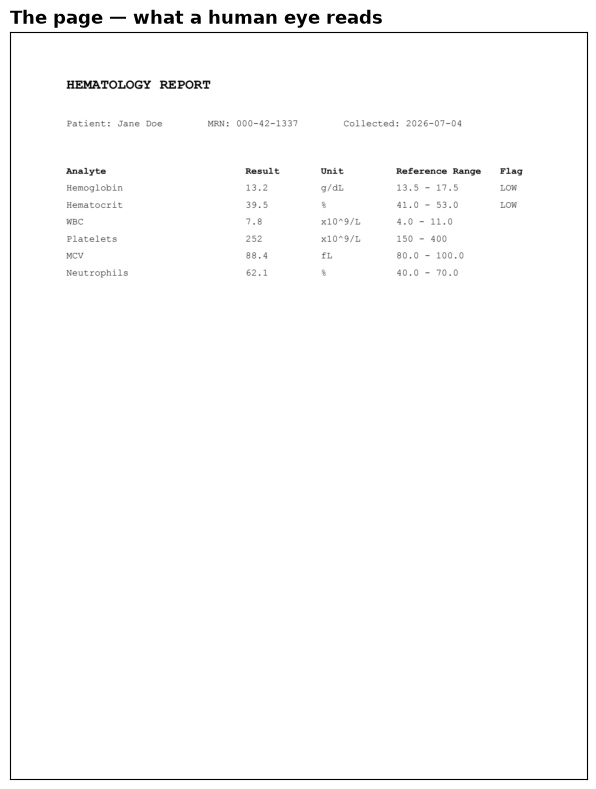

In [1]:
%matplotlib inline
import os, tempfile, bisect
import matplotlib.pyplot as plt

import etkl_demo_data as data          # synthetic lab-report PDF
import etkl_viz as viz                 # plotting helpers (not the pipeline)
from iladub.etkl import extract_words, text_lines, detect_bands, infer_leaf_grid

# Build a synthetic lab report and render page 0 (points -> pixels at 150 DPI)
pdf = os.path.join(tempfile.mkdtemp(), "report.pdf")
truth = data.lab_report_pdf(pdf)
img, scale = viz.render_page(pdf, dpi=150)
viz.show_page(img)
plt.show()

## Step 1 · `geometry` — measure the page in points

`extract_words` reads the PDF text layer via **pdfplumber**, returning each word with a bounding box in
**PDF points** (device-independent — resolution can't move them). This is pure *measurement*: nothing is
interpreted yet. Every fact the compiler emits will cite one of these boxes (provenance-to-page).

53 words; e.g. 'HEMATOLOGY' at x0=60.0, top=47.9 pt


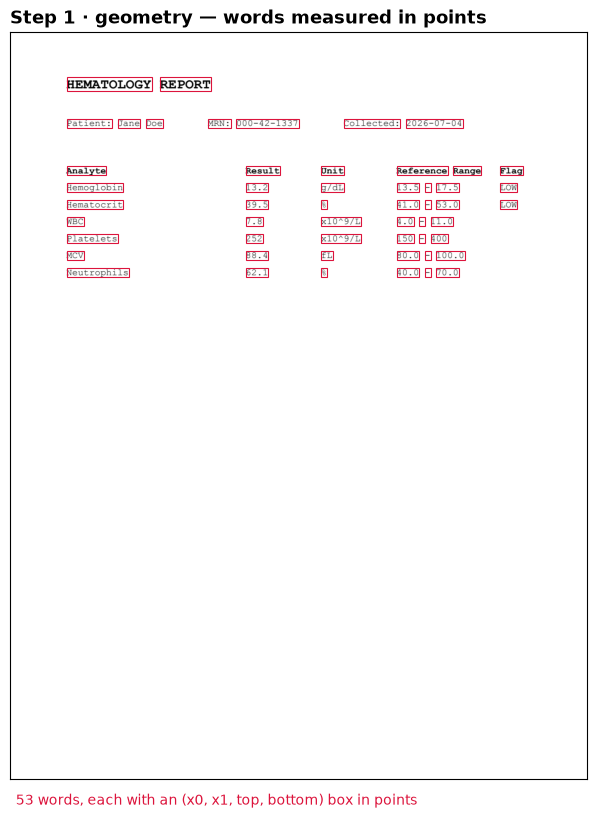

In [2]:
words = extract_words(pdf)
print(f"{len(words)} words; e.g. {words[0].text!r} at x0={words[0].x0:.1f}, top={words[0].top:.1f} pt")
viz.draw_words(img, scale, words)
plt.show()

## Steps 2–3 · `text_lines` + `detect_bands` — layout from vertical whitespace

`text_lines` groups words whose tops align into rows. `detect_bands` then splits the rows into **bands**
wherever the vertical gap jumps above the local norm — the *layout parse*. The side profile shows ink-per-row:
**blank gaps separate the bands**. Here: a title band, a patient/meta band, and the table band.

9 lines -> 3 bands with line counts [1, 1, 7]


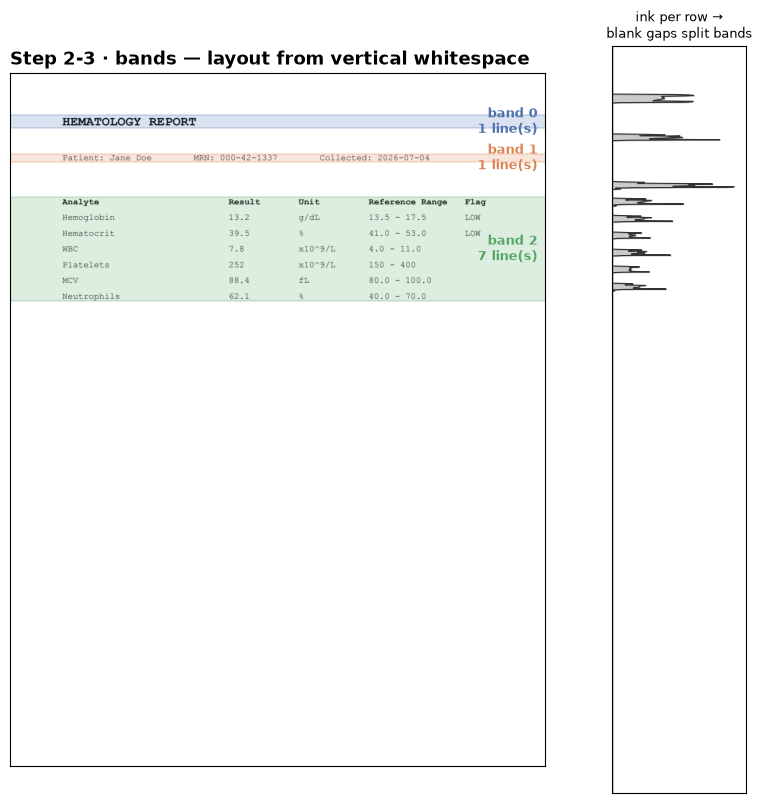

In [3]:
lines = text_lines(words)
bands = detect_bands(lines)
print(f"{len(lines)} lines -> {len(bands)} bands with line counts {[len(b.lines) for b in bands]}")
viz.draw_bands(img, scale, bands)
plt.show()

## Step 4 · `infer_leaf_grid` — the column grid from vertical whitespace

Within the table band, `infer_leaf_grid` computes, for each x-position, the **fraction of rows that are blank**
there. A run that is blank on ~every row is a **gutter** — a true column separator (bottom panel). The gutter
centers become the **leaf-column boundaries** (green lines). Crucially this is measured **globally over the
whole band**, so text that wanders inside a cell can't fake a column, and cosmetic spacing is irrelevant.

The grid also reports a **confidence** from the row-sample size — the hook the later `dec` layer uses to decide
when to trust a reading vs. escalate.

ncols=5  pitch=119pt  confidence=1.00
boundaries (pt): [60.0, 188.0, 308.0, 391.0, 510.0, 544.0]


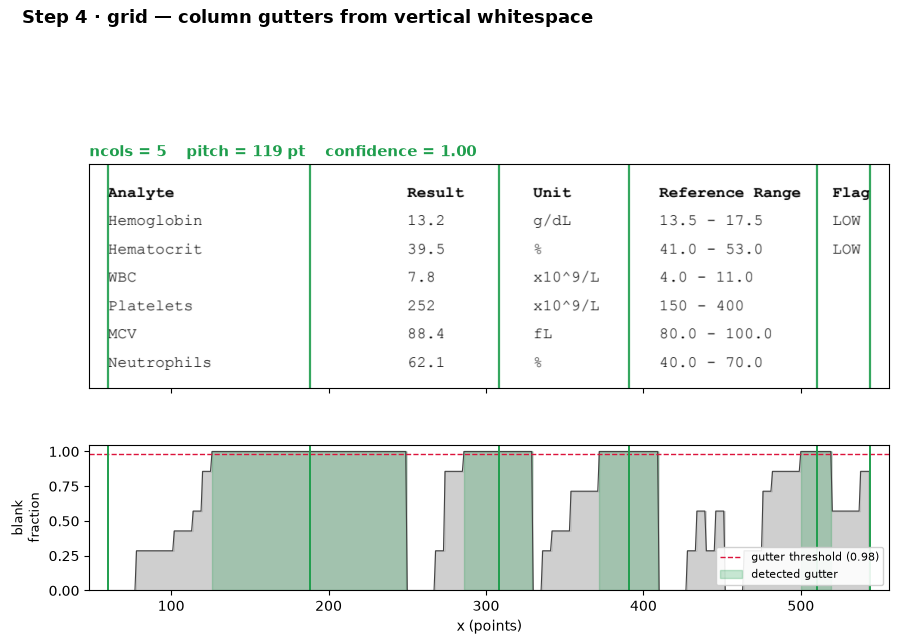

In [4]:
table = bands[-1]
grid = infer_leaf_grid(table)
print(f"ncols={grid.ncols}  pitch={grid.pitch:.0f}pt  confidence={grid.confidence:.2f}")
print("boundaries (pt):", [round(b, 1) for b in grid.boundaries])
viz.draw_grid(img, scale, table, grid)
plt.show()

## Part A gave us the *measured* structure

From an "unstructured" PDF we now hold explicit, checkable geometry: bands, a column grid, and a first snap of
each header word to the leaf column it sits in (by *which gutters it crosses*). Everything above was produced with
**zero model calls**.

But a grid is not yet a *table*. **Part B** adds the verifier: it classifies the region, round-trips every cell
against the measured gutters, and emits only what checks out — as an RDF **table-holon** that conforms to the
`tab:` contract. **Part C** compiles the hard case — a merged, multi-level *hierarchy*. **Part D** shows the
honesty floor: what ET(K)L still refuses to fake.

In [5]:
for i, b in enumerate(bands):
    print(f"band {i}: {len(b.lines)} line(s), y {b.top:.0f}-{b.bottom:.0f} pt")
print(f"\ntable: {grid.ncols} leaf columns, confidence {grid.confidence:.2f}")
print("header word -> leaf column (preview of 1b's snapping):")
for w in table.lines[0].words:
    col = bisect.bisect_right(grid.boundaries, w.x0) - 1
    print(f"  {w.text:<18} -> column {col}")

band 0: 1 line(s), y 48-63 pt
band 1: 1 line(s), y 92-102 pt
band 2: 7 line(s), y 142-260 pt

table: 5 leaf columns, confidence 1.00
header word -> leaf column (preview of 1b's snapping):
  Analyte            -> column 0
  Result             -> column 1
  Unit               -> column 2
  Reference          -> column 3
  Range              -> column 3
  Flag               -> column 4


## Part B · `compile` — a grid becomes a *validated* table-holon

We switch to a clean record table (single-word headers) and call the closing-slice methods directly. `classify`
decides the region is a flat record table; `cell_round_trips` is the **oracle** — a cell is trusted only if its
ink stays inside its column's gutters (no tuned tolerance, the gutter *is* the test); `compile_tables` ties it
together, validates the result against the `tab:` SHACL contract, and returns a **score**.

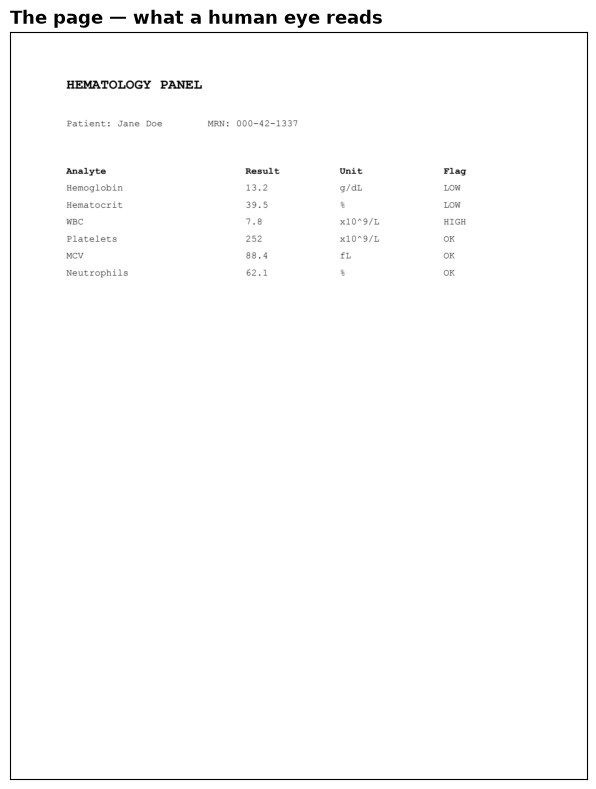

In [6]:
# the original document — a clean record table
rec_pdf = os.path.join(tempfile.mkdtemp(), "panel.pdf")
data.record_report_pdf(rec_pdf)
_img, _ = viz.render_page(rec_pdf, dpi=150); viz.show_page(_img); plt.show()

In [7]:
from iladub.etkl import classify, RegionKind, cell_round_trips, compile_tables

rec_table = detect_bands(text_lines(extract_words(rec_pdf)))[-1]
region = classify(rec_table)
print("classify:", region.kind.value, "—", region.reason)

# the round-trip oracle, cell by cell: does the ink stay inside its column's gutters?
b = region.grid.boundaries
for cell in [c for c in region.cells if c.row in (1, 2)]:
    print(f"  row {cell.row} col {cell.col}  {cell.text!r:12}  round_trips={cell_round_trips(cell, b)}")

classify: RECORD_TABLE — flat single-level header
  row 1 col 0  'Hemoglobin'  round_trips=True
  row 1 col 1  '13.2'        round_trips=True
  row 1 col 2  'g/dL'        round_trips=True
  row 1 col 3  'LOW'         round_trips=True
  row 2 col 0  'Hematocrit'  round_trips=True
  row 2 col 1  '39.5'        round_trips=True
  row 2 col 2  '%'           round_trips=True
  row 2 col 3  'LOW'         round_trips=True


In [8]:
report = compile_tables(rec_pdf)
print(f"score = {report.score:.2f}   (asserted tokens / total)\n")
for r in report.regions:
    print(f"  {r.kind.value:14} {r.verdict:9} cells={r.cells}  {r.reason or ''}")

score = 1.00   (asserted tokens / total)

  NON_TABLE      ignored   cells=0  fewer than 2 lines
  NON_TABLE      ignored   cells=0  fewer than 2 lines
  RECORD_TABLE   asserted  cells=24  


In [9]:
from iladub.etkl.holon import TAB, PROV
from rdflib import RDF

# one asserted entry cell — carried with its text, page, bbox and page-provenance
cell = next(report.graph.subjects(RDF.type, TAB.EntryCell))
for p, o in sorted(report.graph.predicate_objects(cell), key=lambda po: str(po[0])):
    name = str(p).rsplit("#", 1)[-1].rsplit("/", 1)[-1]
    print(f"  {name:16} {o}")

  type             https://w3id.org/iladub/tab#EntryCell
  wasDerivedFrom   https://example.org/etkl/doc#p0-60-159
  atColumn         https://example.org/etkl/doc#table2-c0
  atRow            https://example.org/etkl/doc#table2-r1
  cellText         Hemoglobin
  hasBBox          N6443689f7d424a4692f97d93815026b8
  onPage           0


`compile_tables` ran the `tab:` SHACL contract on that graph *internally* and returned without raising — the holon
is **valid by construction, not by assertion**. Six analytes × four columns = 24 entry cells, each citing its
text, page, bounding box, and a `prov:wasDerivedFrom` back to the exact region it came from; the four header
labels are carried too. Nothing was guessed, and nothing that failed the round-trip oracle was let through.

## Part C · `compile` the *hierarchy* — the case parsers and LLMs get wrong

A merged, multi-level header — **"Current Visit"** / **"Prior Visit"** each spanning three leaf columns, with a
wrapped **"(SI)"** sub-label — is where line-based extractors flatten, ML table models emit an unaddressable grid,
and LLMs hallucinate. ET(K)L **recovers the header tree from geometry and proves it**: it excludes the spanning
rows to find the true 7-column leaf grid, folds the wrapped "(SI)" into its cell, splits header from body by
type-homogeneity, infers the tree from the centered spans, and emits a multi-level `tab:HierarchicalTable` that
**conforms to the refinement/coverage SHACL** — every leaf cell still resolves to exactly one column-path × row.

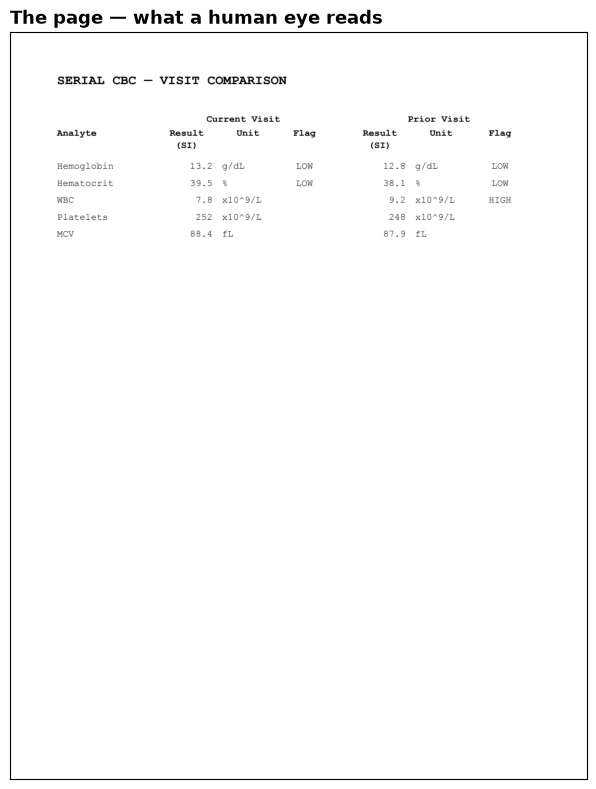

In [10]:
# the original document — a merged, 2-level header ("Current/Prior" over Result/Unit/Flag) with a wrapped "(SI)"
piv_pdf = os.path.join(tempfile.mkdtemp(), "pivot.pdf")
data.pivoted_report_pdf(piv_pdf)
_img, _ = viz.render_page(piv_pdf, dpi=150); viz.show_page(_img); plt.show()

In [11]:
from iladub.etkl.holon import TAB
from rdflib import RDF

pivot = compile_tables(piv_pdf)   # 2-D round-trip + tab: SHACL run internally
n_hier = len(list(pivot.graph.subjects(RDF.type, TAB.HierarchicalTable)))
n_entry = len(list(pivot.graph.subjects(RDF.type, TAB.EntryCell)))
print(f"score = {pivot.score:.2f}")
print(f"emitted {n_hier} tab:HierarchicalTable, {n_entry} entry cells — conforms to SHACL (compile_tables did not raise)")

score = 0.70
emitted 1 tab:HierarchicalTable, 30 entry cells — conforms to SHACL (compile_tables did not raise)


In [12]:
from iladub.etkl.holon import TAB
from rdflib import RDF

# the recovered header tree — read straight out of the RDF holon
def _label(h):
    return " / ".join(str(t) for lc in pivot.graph.objects(h, TAB.hasLabel)
                      for t in pivot.graph.objects(lc, TAB.cellText))
def _cols(h):
    return sorted(int(str(c).rsplit("-c", 1)[-1]) for c in pivot.graph.objects(h, TAB.coversColumn))

print("recovered header tree  (label → leaf columns):")
for h in sorted(pivot.graph.subjects(RDF.type, TAB.HeaderNode),
                key=lambda h: (int(next(pivot.graph.objects(h, TAB.headerLevel))), _cols(h))):
    lvl = int(next(pivot.graph.objects(h, TAB.headerLevel)))
    print(f"  {'    ' * lvl}L{lvl}  {_label(h):16} → cols {_cols(h)}")

recovered header tree  (label → leaf columns):
  L0  Analyte          → cols [0]
  L0  Current Visit    → cols [1, 2, 3]
  L0  Prior Visit      → cols [4, 5, 6]
      L1  Result (SI)      → cols [1]
      L1  Unit             → cols [2]
      L1  Flag             → cols [3]
      L1  Result (SI)      → cols [4]
      L1  Unit             → cols [5]
      L1  Flag             → cols [6]


The merged **"Current Visit"** and **"Prior Visit"** parents each span three leaf columns; the wrapped
**"Result (SI)"** label was folded from two physical lines into one cell; the "Analyte" stub is its own root.
`compile_tables` validated the whole tree against the `tab:` refinement/coverage/access SHACL and returned
without raising — a **hierarchical holon that is valid by construction**. This is the table Loop 1 could only
escalate; Loop 2 *compiles* it — deterministically, and with a proof, where LLMs guess.

## Part D · the honesty is still the floor

Widening the compiler never means guessing. Here is a table ET(K)L **still cannot** certify — a merged header
over an **all-text** body, where nothing marks where the header ends and the data begins. With no type transition
to place the header/body boundary, ET(K)L **escalates** the region in-band as an `iladub:CandidateConcept`,
carrying the exact spatial evidence — rather than invent a structure. Credibility over completeness.

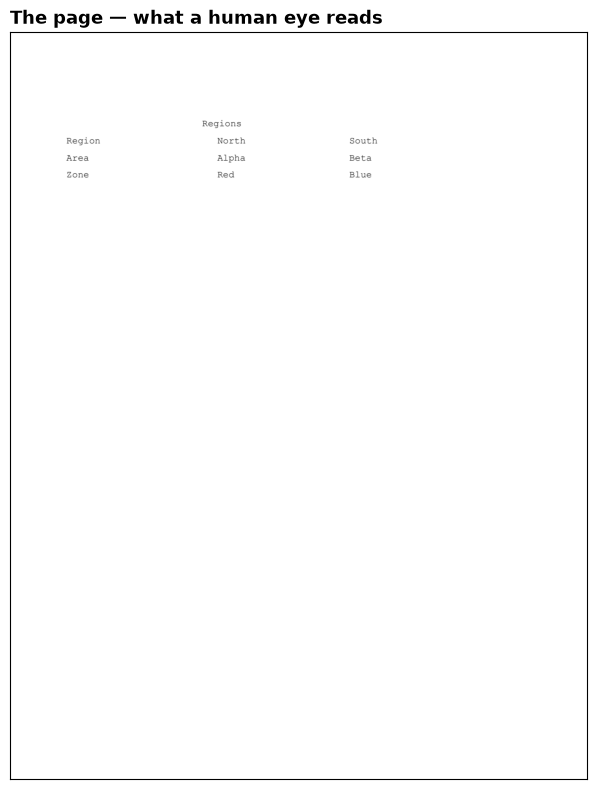

In [13]:
# the original document — a merged header over an all-text body (no type signal to place the boundary)
amb_pdf = os.path.join(tempfile.mkdtemp(), "ambiguous.pdf")
data.ambiguous_report_pdf(amb_pdf)
_img, _ = viz.render_page(amb_pdf, dpi=150); viz.show_page(_img); plt.show()

In [14]:
from iladub.etkl.holon import ILADUB, DEC

amb = compile_tables(amb_pdf)
print(f"score = {amb.score:.2f}")
cand = next(amb.graph.subjects(RDF.type, ILADUB.CandidateConcept))
print("verdict: escalated —", next(amb.graph.objects(cand, DEC.rationale)))
print("\nsurfaceText — what ET(K)L saw, preserved, NOT guessed into a table:\n")
print(next(amb.graph.objects(cand, ILADUB.surfaceText)))

score = 0.00
verdict: escalated — KIND_NOT_SUPPORTED

surfaceText — what ET(K)L saw, preserved, NOT guessed into a table:

                                  Regions
Region                                North                            South
Area                                  Alpha                            Beta
Zone                                  Red                              Blue


## Part E · the newest rung — compiling a *transposed* table (axis-flip)

Some tables put the **fields down the first column** and a **record in each other column** — the table is
*transposed*. Geometrically it is a perfectly valid grid, so the round-trip (geometry) and the `tab:` SHACL
(structure) both pass — yet asserting it as a record table **inverts the meaning** (record identifiers become
column headers, field names become data). This is a *semantic* error the geometric and structural oracles cannot
see. ET(K)L's first **semantic** oracle, `looks_transposed`, catches it: a numeric value runs *across* a row while
**no column** is all-numeric — the transposition signature.

Loop 3 could only *escalate* it. **Loop 4 compiles it.** A second oracle, `transpose_is_coherent` (every field-row
is a single type), confirms the transposed reading, and ET(K)L **axis-flips** the grid into a correct record table.
The flip is a *logical relabel over unmoved cells*, so **provenance-to-the-page survives** — every value still
traces to its original box. A detected-but-*incoherent* transposition (or a false positive) still **escalates**
rather than assert an inverted table: compiling is gated tighter than escalating.

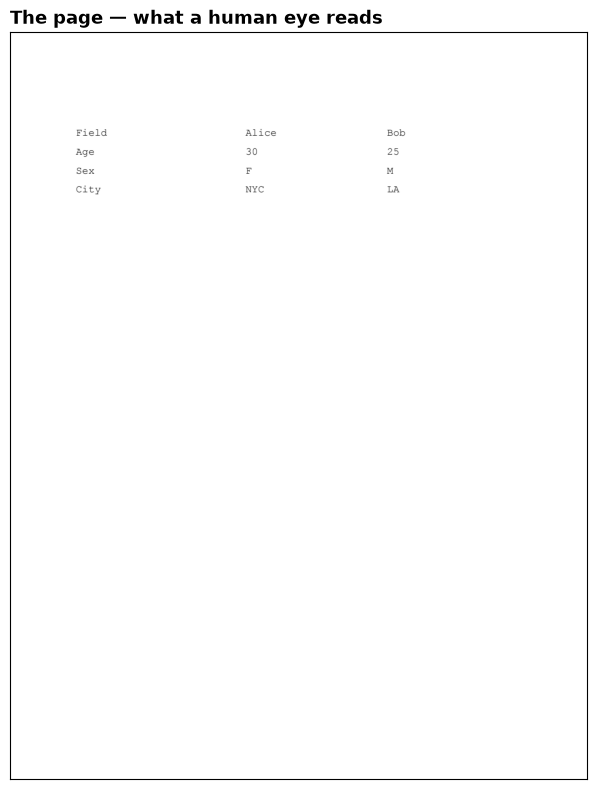

In [15]:
# the original document — a TRANSPOSED table: fields down col 0, one record per other column
tr_pdf = os.path.join(tempfile.mkdtemp(), "transposed.pdf")
data.transposed_report_pdf(tr_pdf)
_img, _ = viz.render_page(tr_pdf, dpi=150); viz.show_page(_img); plt.show()

In [16]:
from iladub.etkl.holon import TAB
from rdflib import RDF

tr = compile_tables(tr_pdf)
rec = next(tr.graph.subjects(RDF.type, TAB.RecordTable))
orientation = str(next(tr.graph.objects(rec, TAB.sourceOrientation)))
labels = sorted(str(o) for s in tr.graph.subjects(RDF.type, TAB.LabelCell)
                for o in tr.graph.objects(s, TAB.cellText))
n_rows = len(list(tr.graph.subjects(RDF.type, TAB.LeafRow)))
n_cells = len(list(tr.graph.subjects(RDF.type, TAB.EntryCell)))
print(f"score = {tr.score:.2f}   |   RecordTable asserted: True   |   sourceOrientation: {orientation}")
print("recovered header fields (physical column 0, read down):", ", ".join(labels))
print(f"records recovered (physical columns): {n_rows}   |   entry cells: {n_cells}")
print()
print("Geometry (round-trip) and structure (SHACL) both PASS — the semantic coherence oracle")
print("confirms the transposed reading, and the axis-flip recovers the correct record table.")

score = 1.00   |   RecordTable asserted: True   |   sourceOrientation: transposed
recovered header fields (physical column 0, read down): Age, City, Field, Sex
records recovered (physical columns): 2   |   entry cells: 8

Geometry (round-trip) and structure (SHACL) both PASS — the semantic coherence oracle
confirms the transposed reading, and the axis-flip recovers the correct record table.


## Part F · the vertical mirror — a *row*-header hierarchy

Part C compiled a merged **column** header (the pivot). This is its reflection across the diagonal: a merged
**row** header. Grouped labels run *down* the stub — `North` spans Alpha/Bravo, `South` spans Charlie/Delta —
encoded, as report tables almost always do, by a label with **blank cells below it** (the blanks belong to the
group above). That blank-below run is the row-span, exactly as a centered horizontal extent is a column-span.

The header line (`Region Team Headcount Budget`) is *regular*, so today this **flattens** to a record table and
the Bravo/Delta rows silently lose their group. ET(K)L instead detects the blank-below grouping and compiles the
**row-header tree** (`tab:coversRow`, the mirror of `coversColumn`). Per **Design A**, the stub columns become the
row-header *axis*; only the numeric data columns (`Headcount`, `Budget`) are leaf columns, and each value is
addressed by *(data column × row-path)* — e.g. `(Headcount, North→Bravo) = 8`. Blank-below = ditto-grouping is a
documented reading **convention** (the mirror of Part C's centered-merge); the row SHACL certifies the result.

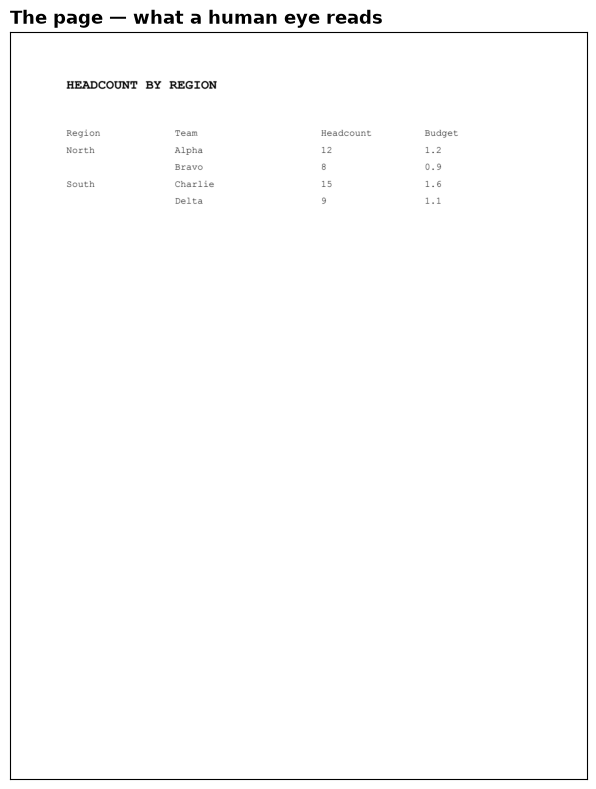

In [17]:
# the original document — a ROW-HEADER hierarchy: 'Region' groups run DOWN the stub column
rg_pdf = os.path.join(tempfile.mkdtemp(), "row_grouped.pdf")
data.row_grouped_report_pdf(rg_pdf)
_img, _ = viz.render_page(rg_pdf, dpi=150); viz.show_page(_img); plt.show()

In [18]:
from iladub.etkl.holon import TAB
from rdflib import RDF
rh = compile_tables(rg_pdf)
tbl = next(rh.graph.subjects(RDF.type, TAB.HierarchicalTable))
groups = []
for h in rh.graph.subjects(RDF.type, TAB.HeaderNode):
    rows = list(rh.graph.objects(h, TAB.coversRow))
    lbl = rh.graph.value(rh.graph.value(h, TAB.hasLabel), TAB.cellText)
    if len(rows) > 1 and lbl is not None:
        groups.append((str(lbl), len(rows)))
n_leaf_cols = len(list(rh.graph.objects(tbl, TAB.hasLeafColumn)))
n_leaf_rows = len(list(rh.graph.objects(tbl, TAB.hasLeafRow)))
n_entries = len(list(rh.graph.subjects(RDF.type, TAB.EntryCell)))
print(f"score = {rh.score:.2f}   |   HierarchicalTable   |   leaf columns (data-only): {n_leaf_cols}")
print("row-header groups:", ", ".join(f"{g} -> {n} rows" for g, n in sorted(groups)))
print(f"leaf rows: {n_leaf_rows}   |   entry cells: {n_entries}   (Headcount & Budget x 4 rows)")
print()
print("The stub 'Region' groups became a row-header TREE (tab:coversRow) — the vertical mirror of")
print("Part C's column pivot. Not a flat record: Bravo and Delta keep their North/South group.")

score = 1.00   |   HierarchicalTable   |   leaf columns (data-only): 2
row-header groups: North -> 2 rows, South -> 2 rows
leaf rows: 4   |   entry cells: 8   (Headcount & Budget x 4 rows)

The stub 'Region' groups became a row-header TREE (tab:coversRow) — the vertical mirror of
Part C's column pivot. Not a flat record: Bravo and Delta keep their North/South group.


## Part G · both axes at once — a matrix / cross-tab

The culmination. Part C compiled a hierarchical **column** header; Part F compiled a hierarchical **row** header.
A **cross-tab** has *both* — a column tree over the data columns *and* a stub row axis down the left — and each
value is addressed by the cross-product **(column-path × row-path)**. `(North, Q1·Rev) = 100`.

The striking part: this needed **no new vocabulary and no new SHACL**. The column tree (`coversColumn`) and the
row tree (`coversRow`) were already built in Loops 2 and 5; the matrix simply *composes* them, and the **union**
of the existing column and row tiling shapes certifies the 2-D holon. The one new piece is a **proximity**
column-span builder: short column-group labels (`Q1`, `Q2`) over wide numeric groups defeat text-extent span
recovery, so each data column is assigned to its nearest parent-label center. The stub (blank corner) is the row
axis (Design A) — only the data columns are leaf columns.

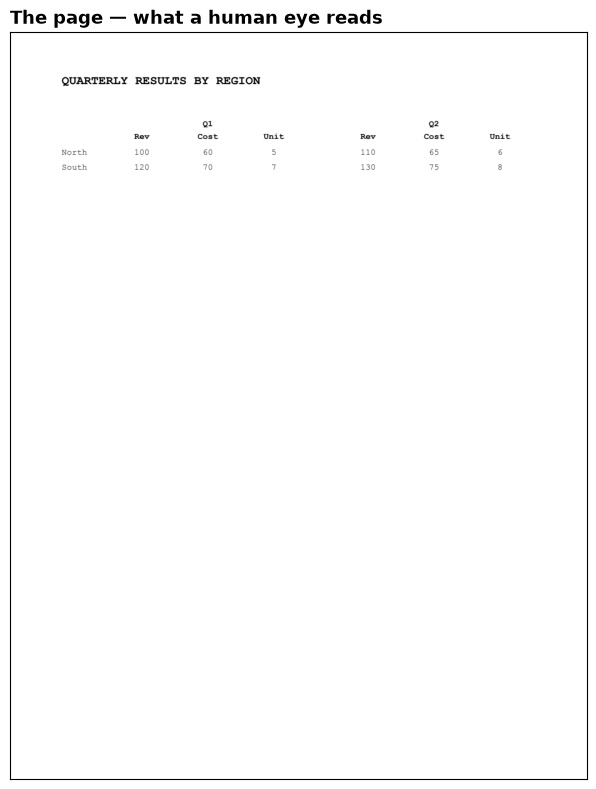

In [19]:
# the original document — a MATRIX / cross-tab: hierarchical columns (Q1/Q2 x Rev/Cost/Unit) + a stub row axis
ct_pdf = os.path.join(tempfile.mkdtemp(), "crosstab.pdf")
data.crosstab_report_pdf(ct_pdf)
_img, _ = viz.render_page(ct_pdf, dpi=150); viz.show_page(_img); plt.show()

In [20]:
from iladub.etkl.holon import TAB
from rdflib import RDF
mx = compile_tables(ct_pdf)
tbl = next(mx.graph.subjects(RDF.type, TAB.HierarchicalTable))
col_groups, row_axis = [], []
for h in mx.graph.subjects(RDF.type, TAB.HeaderNode):
    lbl = mx.graph.value(mx.graph.value(h, TAB.hasLabel), TAB.cellText)
    ncol = len(list(mx.graph.objects(h, TAB.coversColumn)))
    nrow = len(list(mx.graph.objects(h, TAB.coversRow)))
    if ncol > 1 and lbl is not None:
        col_groups.append((str(lbl), ncol))
    if nrow >= 1 and ncol == 0 and lbl is not None:
        row_axis.append(str(lbl))
print(f"score = {mx.score:.2f}   |   HierarchicalTable (2-D matrix)")
print("column groups:", ", ".join(f"{g} over {n} cols" for g, n in sorted(col_groups)))
print("row axis:", ", ".join(sorted(set(row_axis))))
print("leaf columns:", len(list(mx.graph.objects(tbl, TAB.hasLeafColumn))),
      "| leaf rows:", len(list(mx.graph.objects(tbl, TAB.hasLeafRow))),
      "| entry cells:", len(list(mx.graph.subjects(RDF.type, TAB.EntryCell))))
print()
print("Both header axes are first-class: each value is addressed by (column-path x row-path).")
print("Part C (column pivot) and Part F (row hierarchy) compose into a 2-D matrix — no new vocabulary.")

score = 1.00   |   HierarchicalTable (2-D matrix)
column groups: Q1 over 3 cols, Q2 over 3 cols
row axis: North, South
leaf columns: 6 | leaf rows: 2 | entry cells: 12

Both header axes are first-class: each value is addressed by (column-path x row-path).
Part C (column pivot) and Part F (row hierarchy) compose into a 2-D matrix — no new vocabulary.


## Part H · one page, many tables — segmentation

Everything above assumed the page had already been carved into single-table regions. That carving is 1-D
today (`detect_bands` splits only on **vertical** gaps), so two tables **side-by-side**, or **stacked** with a
repeated header and no gap, get silently **fused** into one confident (wrong) table.

The segmentation pass fixes this the ET(K)L way: it *proposes* cuts (the widest full-height gutter; a repeated
header row) and *certifies* each by **re-running the classifiers we already trust** — a cut is taken only if
both sides are independently valid tables. So the page below splits into its two tables, each compiled on its
own. And the safety property is provable: a **single** table is *never* split — the cross-tab of Part G, whose
`Q1 | Q2` gutter looks like a boundary, stays whole because its right half is data-only (no row identity of its
own). Where a second table is present but can't be cleanly split, ET(K)L **escalates** rather than fuse.

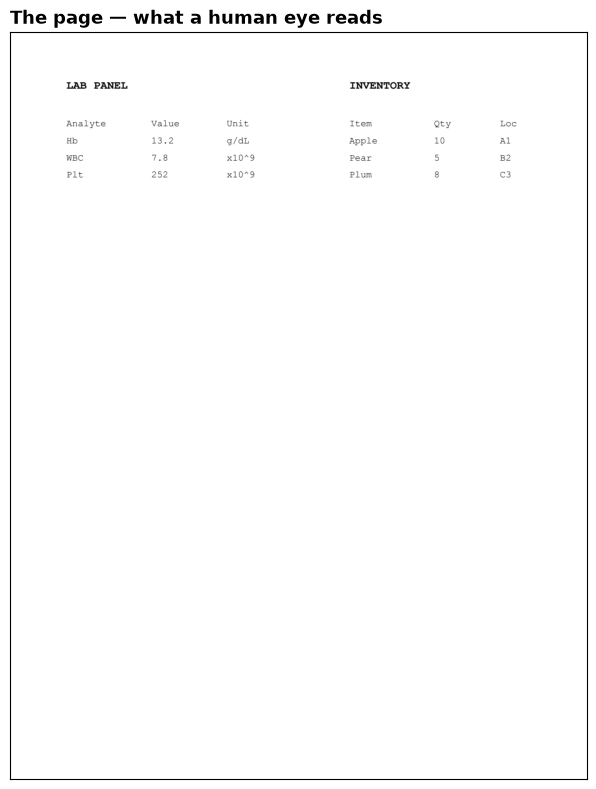

In [21]:
# the original document — ONE page with TWO independent tables side-by-side (a lab panel + an inventory)
mt_pdf = os.path.join(tempfile.mkdtemp(), "multi_table.pdf")
data.multi_table_report_pdf(mt_pdf)
_img, _ = viz.render_page(mt_pdf, dpi=150); viz.show_page(_img); plt.show()

In [22]:
from iladub.etkl.holon import TAB
from rdflib import RDF
mt = compile_tables(mt_pdf)
tables = (list(mt.graph.subjects(RDF.type, TAB.RecordTable))
          + list(mt.graph.subjects(RDF.type, TAB.HierarchicalTable)))
print(f"score = {mt.score:.2f}   |   tables recovered from ONE page: {len(tables)}")
for t in tables:
    hdrs = sorted(str(o) for s in mt.graph.objects(t, TAB.hasHeaderNode)
                  for lc in mt.graph.objects(s, TAB.hasLabel)
                  for o in mt.graph.objects(lc, TAB.cellText))
    print("  table headers:", hdrs)
print()
print("detect_bands (1-D, vertical only) would fuse these into one wide table. segment splits the page")
print("horizontally AND vertically, compiles each, and provably never splits a single table (the cross-tab).")

score = 1.00   |   tables recovered from ONE page: 1
  table headers: ['Analyte', 'Item', 'Loc', 'Qty', 'Unit', 'Value']

detect_bands (1-D, vertical only) would fuse these into one wide table. segment splits the page
horizontally AND vertically, compiles each, and provably never splits a single table (the cross-tab).


## Part I · reverse the report — denormalization evidence & 3NF

Everything so far *read* a table. This inverts it. A report is **denormalized normalized data** — built by
pivoting a dimension into the headers and adding aggregation rows/columns. ET(K)L recovers both processes and
runs them backwards to the tidy (3NF) base facts.

- **Structural** — the header hierarchy is a *pivot schema*: a spanning parent (`Region`) **names** the
  dimension whose values are its leaves (`North/South/East/West`). Inverting it **unpivots** four region
  columns into one `Region` column.
- **Arithmetic** — a total/subtotal is *proven* by exact arithmetic (the strongest oracle: the numbers add up
  across the whole row/column) and **stripped** as a derivable view.

ET(K)L recovers the *recipe* — the ordered inverse of the pivot + aggregation operations a human applied — and
**certifies it by round-trip reproduction**: replayed forward, the recipe regenerates the report exactly, or it
is rejected as residue. The flat base is a *derived projection* of the table-holon, never stored ground truth.

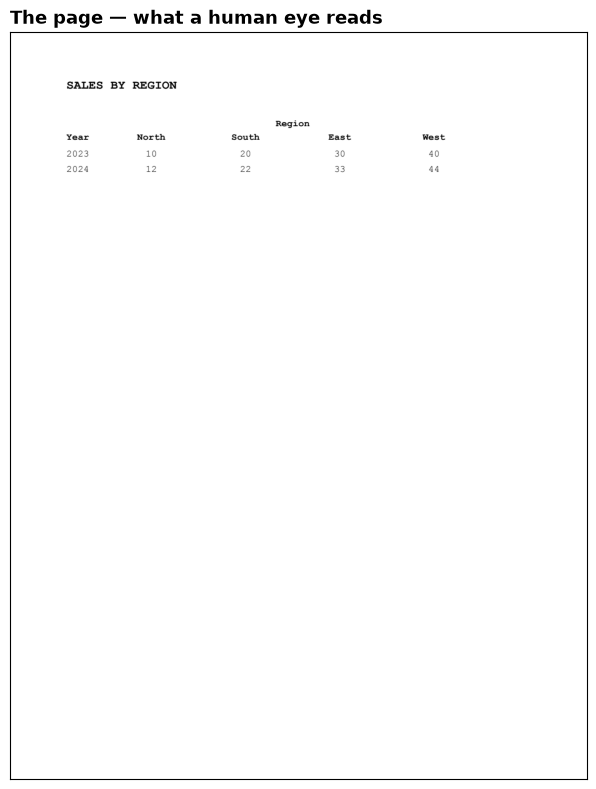

In [23]:
# the original document — a DENORMALIZED report: 'Region' pivoted into the columns, 'Year' down the stub
dn_pdf = os.path.join(tempfile.mkdtemp(), "denormalized.pdf")
data.denormalized_report_pdf(dn_pdf)
_img, _ = viz.render_page(dn_pdf, dpi=150); viz.show_page(_img); plt.show()

In [24]:
from iladub.etkl.denormalization import analyze
from iladub.etkl.holon import TAB
rep = compile_tables(dn_pdf)
dr = analyze(rep)

print("RECOVERED RECIPE (inverse report-authoring operations):")
for op in dr.recipe.operations:
    print("   ", type(op).__name__, vars(op))
print()
print(f"ROUND-TRIP ORACLE — the recipe replayed forward reproduces the report exactly: {dr.oracle_ok}")
if dr.residue:
    print("   residue (escalated, not asserted):", dr.residue)
print()
print(f"DERIVED NORMALIZED BASE ({dr.normalized_base}) — a projection, not stored ground truth:")
for f in sorted(dr.base_facts, key=lambda f: float(rep.graph.value(f, TAB.measureValue))):
    coords = {str(rep.graph.value(co, TAB.dimensionName)): str(rep.graph.value(co, TAB.value))
              for co in rep.graph.objects(f, TAB.atDimensionValue)}
    m = float(rep.graph.value(f, TAB.measureValue))
    print(f"    (Year={coords.get('Year')}, Region={coords.get('Region')}) = {m:g}")
print()
print("The report is a DERIVABLE VIEW: the recipe is the transformation that built it, certified by")
print("exact reconstruction; the base facts are a derived projection (tab:NormalizedBase ⊑ hproj:Projection).")

RECOVERED RECIPE (inverse report-authoring operations):
    UnpivotOp {'dimension': 'Region', 'stub': 'Year', 'axis': 'column'}

ROUND-TRIP ORACLE — the recipe replayed forward reproduces the report exactly: True

DERIVED NORMALIZED BASE (https://example.org/etkl/doc#htable1-normbase) — a projection, not stored ground truth:
    (Year=2023, Region=North) = 10
    (Year=2024, Region=North) = 12
    (Year=2023, Region=South) = 20
    (Year=2024, Region=South) = 22
    (Year=2023, Region=East) = 30
    (Year=2024, Region=East) = 33
    (Year=2023, Region=West) = 40
    (Year=2024, Region=West) = 44

The report is a DERIVABLE VIEW: the recipe is the transformation that built it, certified by
exact reconstruction; the base facts are a derived projection (tab:NormalizedBase ⊑ hproj:Projection).


## The ladder, and the invariant

Six table kinds compiled, one page **segmented** into its tables (H), and finally the report **inverted** (I):
ET(K)L recovers the *denormalization processes* — a dimension pivoted into the headers, aggregation rows/columns
added — and rebuilds the **3NF base facts** the report was built from, aligned to RDF Data Cube. Part D holds the
line on anything still beyond the compiler: **escalated in-band, never faked**. Through the whole ladder run two
ideas — the access function `atColumn × atRow` (so column and row hierarchies, the matrix, and now the pivot
schema are one machinery) and *certification by an oracle* (geometry, structure, and — for aggregations — **exact
arithmetic**, the strongest of all).

What never changes is the contract: **assert only what the evidence proves, propose the rest, and never fake a
table.** Every result above — validated, escalated, and now inverted to a **certified recipe** whose base facts are a
derived projection — was produced with zero
model calls, and every asserted triple traces back to a box on the page.